In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def main(seed):
    # --- 1. 参数设置 ---
    n = 16000#1400
    alpha = 2.75
    Rmin_mm, Rmax_mm = 0.06, 0.8
    px_size = 0.2 # 0.1
    width, height = 1000,1000 #512, 512
    L = 200 #100.0  # mm
    #seed = 4
    np.random.seed(seed)
    # --- 2. 幂律分布采样 ---
    # Inverse transform sampling
    U = np.random.rand(n)
    term1 = Rmin_mm**(1 - alpha)
    term2 = Rmax_mm**(1 - alpha)
    R_mm = (term1 + U * (term2 - term1))**(1 / (1 - alpha))
    R_mm = R_mm[R_mm <= Rmax_mm]  # Truncate
    R_px = np.round(R_mm / px_size).astype(int)

    print(f"Generated {len(R_mm)} holes. Mean R: {np.mean(R_mm):.3f} mm")

    # --- 3. 网格与 Helper 函数 ---
    x = np.linspace(0, L, width)
    y = np.linspace(0, L, height)
    XX, YY = np.meshgrid(x, y) # shape (height, width)

    def stamp_ellipse(mask, cx, cy, a_mm, b_mm, theta, xx, yy, x_ax, y_ax):
        """在 mask 上局部盖一个椭圆"""
        box = max(a_mm, b_mm)
        # 寻找局部索引 (Slicing optimization)
        x_idx = np.where((x_ax >= cx - box) & (x_ax <= cx + box))[0]
        y_idx = np.where((y_ax >= cy - box) & (y_ax <= cy + box))[0]
        
        if len(x_idx) == 0 or len(y_idx) == 0: return mask

        # 提取局部网格
        Xsub = xx[y_idx[:, None], x_idx]
        Ysub = yy[y_idx[:, None], x_idx]
        
        # 平移与旋转
        Xc, Yc = Xsub - cx, Ysub - cy
        cosT, sinT = np.cos(theta), np.sin(theta)
        Xr = cosT * Xc + sinT * Yc
        Yr = -sinT * Xc + cosT * Yc
        
        # 椭圆方程判断
        inside = (Xr/a_mm)**2 + (Yr/b_mm)**2 <= 1
        
        # 更新 Mask (局部操作)
        sub_mask = mask[y_idx[:, None], x_idx]
        sub_mask[inside] = 1
        mask[y_idx[:, None], x_idx] = sub_mask
        return mask

    def save_texture(mask, filename):
        """模拟 MATLAB 的 permute/reshape 保存格式: Header + RGBA flat"""
        # Invert mask: 0=hole, 1=tissue -> 1=hole, 0=tissue for saving? 
        # MATLAB: Anew = double(A==0). 
        Anew = (mask == 0).astype(int)
        
        # 构造 (Height, Width, 4) -> 对应 MATLAB cat(3, Anew, zeros(...,3))
        zeros = np.zeros_like(Anew)
        rgba = np.stack([Anew, zeros, zeros, zeros], axis=2) # Shape: (H, W, 4)
        
        # 对应 MATLAB permute(AAA, [3 1 2]) -> (4, H, W)
        rgba_permuted = np.transpose(rgba, (1, 0, 2))
        
        # Flatten
        data_flat = rgba_permuted.flatten()
        
        # Header: [width, height]
        header = np.array([width, height], dtype=int)
        
        # Save
        final_data = np.concatenate([header, data_flat])
        np.savetxt(filename, final_data.reshape(1, -1), delimiter=',', fmt='%d')
        print(f"Saved: {filename}")

    # --- 4. 生成 Square Mask ---
    M_sq = np.zeros((height, width))

    for r in R_mm:
        # 若要改为圆形，令 a_mm = b_mm = r 即可
        b_mm = r
        a_mm = r
        
        
        cx = a_mm + (L - 2*a_mm) * np.random.rand()
        cy = a_mm + (L - 2*a_mm) * np.random.rand()
        theta = 2 * np.pi * np.random.rand()
        
        M_sq = stamp_ellipse(M_sq, cx, cy, a_mm, b_mm, theta, XX, YY, x, y)

    # 边界墙
    M_sq[:, 0] = 1; M_sq[:, -1] = 1; M_sq[0, :] = 1; M_sq[-1, :] = 1

    # 绘图
    #plt.figure()
    #plt.imshow(M_sq, cmap='gray', origin='lower', extent=[0, L, 0, L])
    #plt.title('Square Domain')
    #plt.show()
    
    # --- 5. 生成 Circle Mask ---
    M_circ = np.zeros((height, width))
    radius_domain = 0.5 * 0.99 * L
    dist0 = np.sqrt((XX - 0.5*L)**2 + (YY - 0.5*L)**2)
    M_circ[dist0 >= radius_domain] = 1

    for r in R_mm:
        b_mm = r
        a_mm = r
        
        valid = False
        while not valid:
            cx, cy = np.random.rand() * L, np.random.rand() * L
            d_center = np.sqrt((cx - 0.5*L)**2 + (cy - 0.5*L)**2)
            if (d_center + a_mm) <= radius_domain:
                valid = True
                
        theta = 2 * np.pi * np.random.rand()
        M_circ = stamp_ellipse(M_circ, cx, cy, a_mm, b_mm, theta, XX, YY, x, y)

    plt.figure()
    plt.imshow(M_circ, cmap='gray', origin='lower', extent=[0, L, 0, L])
    plt.title('Circle Domain')
    plt.show()

    # --- 6. 保存 ---
    save_texture(M_circ, f'maskcircle_{seed}_{width}.csv')

Generated 1400 holes. Mean R: 0.121 mm


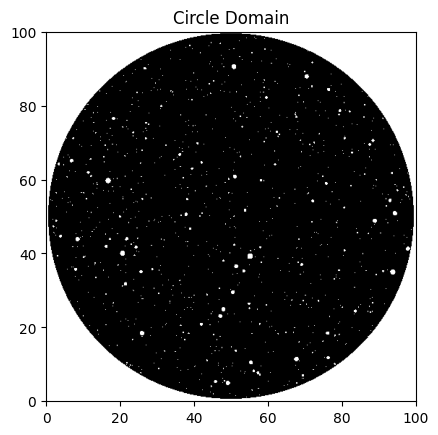

Saved: maskcircle_1_512.csv
Generated 1400 holes. Mean R: 0.122 mm


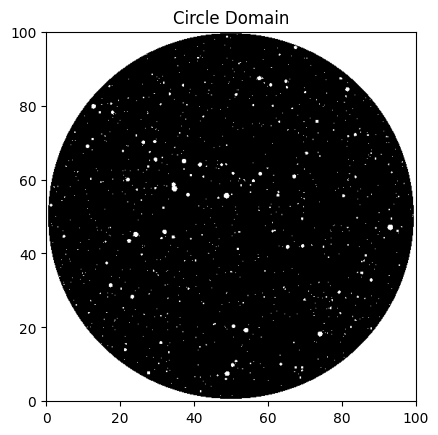

Saved: maskcircle_2_512.csv
Generated 1400 holes. Mean R: 0.123 mm


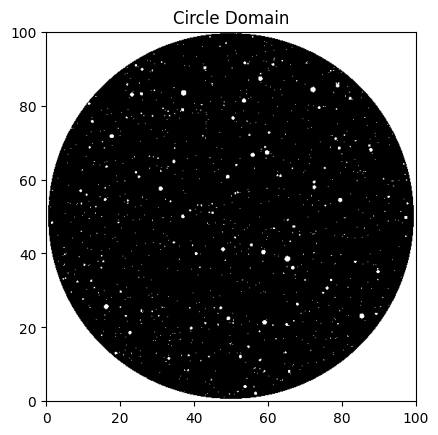

Saved: maskcircle_3_512.csv
Generated 1400 holes. Mean R: 0.123 mm


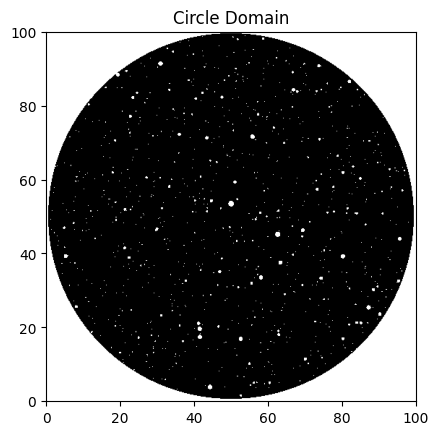

Saved: maskcircle_4_512.csv
Generated 1400 holes. Mean R: 0.121 mm


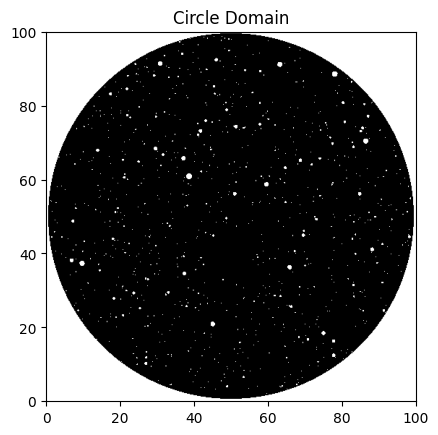

Saved: maskcircle_5_512.csv
Generated 1400 holes. Mean R: 0.121 mm


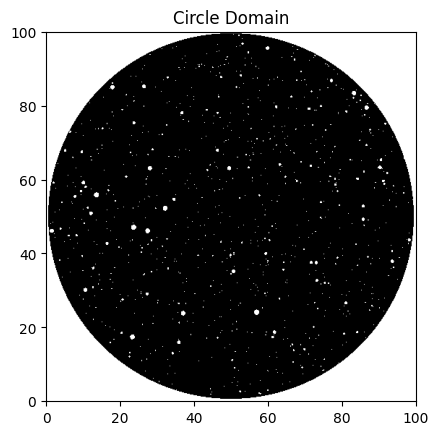

Saved: maskcircle_6_512.csv
Generated 1400 holes. Mean R: 0.119 mm


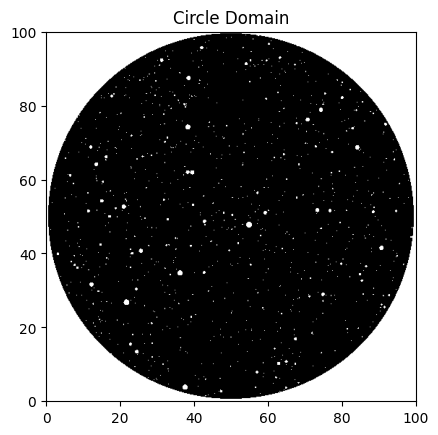

Saved: maskcircle_7_512.csv
Generated 1400 holes. Mean R: 0.121 mm


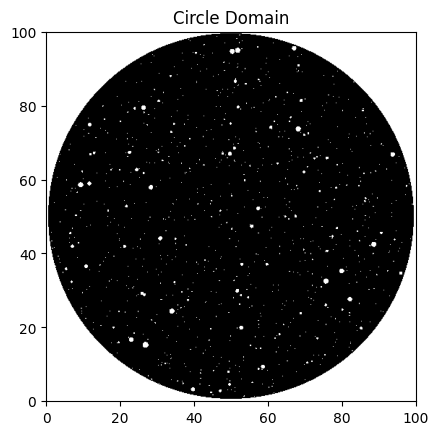

Saved: maskcircle_8_512.csv
Generated 1400 holes. Mean R: 0.120 mm


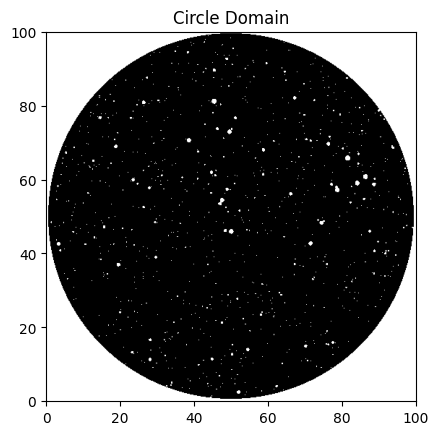

Saved: maskcircle_9_512.csv
Generated 1400 holes. Mean R: 0.120 mm


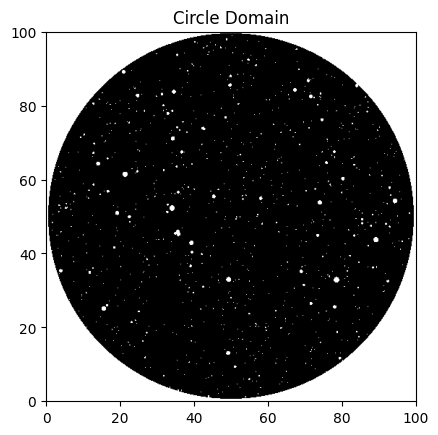

Saved: maskcircle_10_512.csv


In [25]:
for seed in range(1, 11):
    main(seed)